In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedat

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
import os
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# Standard size for custom CNNs
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_relabel(root_path):
    full_ds = datasets.ImageFolder(root_path, transform=transform)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(fruit_classes)}
    filtered_samples = []
    for path, old_label in full_ds.samples:
        cls_name = full_ds.classes[old_label]
        if cls_name in fruit_classes:
            filtered_samples.append((path, class_to_idx[cls_name]))
    full_ds.samples = filtered_samples
    full_ds.imgs = filtered_samples
    full_ds.classes = fruit_classes
    full_ds.class_to_idx = class_to_idx
    return full_ds

base_path = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'
orig_path = os.path.join(base_path, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
aug_path = os.path.join(base_path, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

full_dataset = ConcatDataset([load_and_relabel(orig_path), load_and_relabel(aug_path)])

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total Images for Custom CNN: {len(full_dataset)}")

Total Images for Custom CNN: 3183


In [4]:
class GuavaCNN(nn.Module):
    def __init__(self):
        super(GuavaCNN, self).__init__()
        # Layer 1: Input (3, 224, 224) -> Output (16, 112, 112)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Layer 2: Output (32, 56, 56)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Layer 3: Output (64, 28, 28)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Fully Connected Layers
        # 224 / 2 / 2 / 2 = 28
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 3) # 3 classes
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 64 * 28 * 28) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = GuavaCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Custom CNN initialized.")

Custom CNN initialized.


In [5]:
num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()
    
    # Training Phase
    model.train()
    train_loss, train_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

    # Validation Phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    print(f'Epoch {epoch+1}/{num_epochs} | Time: {time.time()-start_time:.1f}s')
    print(f'  Train -> Loss: {train_loss/len(train_dataset):.4f} Acc: {train_corrects.double()/len(train_dataset):.4f}')
    print(f'  Val   -> Loss: {val_loss/len(val_dataset):.4f} Acc: {val_corrects.double()/len(val_dataset):.4f}')
    print("-" * 45)

Epoch 1/10 | Time: 35.4s
  Train -> Loss: 1.0184 Acc: 0.5664
  Val   -> Loss: 0.6251 Acc: 0.7358
---------------------------------------------
Epoch 2/10 | Time: 20.1s
  Train -> Loss: 0.5292 Acc: 0.7760
  Val   -> Loss: 0.4473 Acc: 0.8071
---------------------------------------------
Epoch 3/10 | Time: 20.6s
  Train -> Loss: 0.3556 Acc: 0.8618
  Val   -> Loss: 0.3182 Acc: 0.8742
---------------------------------------------
Epoch 4/10 | Time: 20.1s
  Train -> Loss: 0.2762 Acc: 0.8914
  Val   -> Loss: 0.2773 Acc: 0.8763
---------------------------------------------
Epoch 5/10 | Time: 20.2s
  Train -> Loss: 0.2032 Acc: 0.9219
  Val   -> Loss: 0.2469 Acc: 0.9140
---------------------------------------------
Epoch 6/10 | Time: 20.1s
  Train -> Loss: 0.1311 Acc: 0.9466
  Val   -> Loss: 0.1929 Acc: 0.9161
---------------------------------------------
Epoch 7/10 | Time: 20.1s
  Train -> Loss: 0.0926 Acc: 0.9695
  Val   -> Loss: 0.2127 Acc: 0.9371
---------------------------------------------

In [7]:
model.eval()
test_corrects = 0
all_preds = []
all_labels = []

print("Running Final Evaluation on Test Dataset...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Stats
        test_corrects += torch.sum(preds == labels.data)
        
        # Store for future analysis if needed
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Accuracy
test_acc = (test_corrects.double() / len(test_dataset)) * 100
print(f"\nCustom CNN Final Test Accuracy: {test_acc:.2f}%")

# --- SAVE THE MODEL ---
# This saves the 'weights' of your custom architecture
save_path = '/kaggle/working/custom_guava_cnn.pth'
torch.save(model.state_dict(), save_path)

print(f"Model successfully saved to: {save_path}")

Running Final Evaluation on Test Dataset...

Custom CNN Final Test Accuracy: 91.00%
Model successfully saved to: /kaggle/working/custom_guava_cnn.pth


Generating predictions for your Custom CNN...


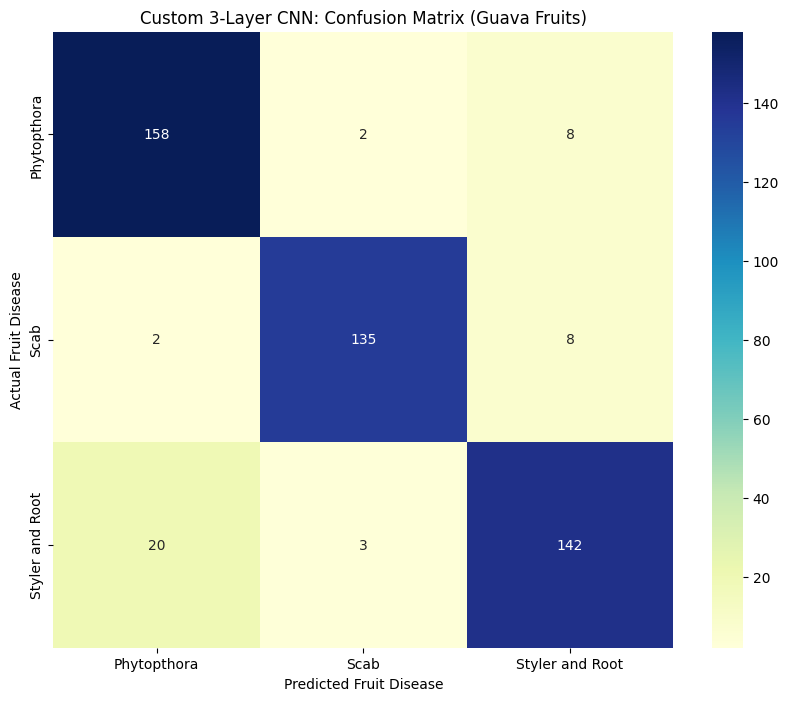


Detailed Classification Report (Custom CNN):
                 precision    recall  f1-score   support

    Phytopthora       0.88      0.94      0.91       168
           Scab       0.96      0.93      0.95       145
Styler and Root       0.90      0.86      0.88       165

       accuracy                           0.91       478
      macro avg       0.91      0.91      0.91       478
   weighted avg       0.91      0.91      0.91       478



In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

# Ensure the model is in eval mode
model.eval()
print("Generating predictions for your Custom CNN...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Define class names for your Guava dataset
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
# Using 'YlGnBu' (Yellow-Green-Blue) to make your custom model stand out
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Fruit Disease')
plt.ylabel('Actual Fruit Disease')
plt.title('Custom 3-Layer CNN: Confusion Matrix (Guava Fruits)')
plt.show()

# 5. Print Detailed Metrics
print("\nDetailed Classification Report (Custom CNN):")
print(classification_report(all_labels, all_preds, target_names=class_names))

Calculating probabilities for Custom CNN ROC Curve...


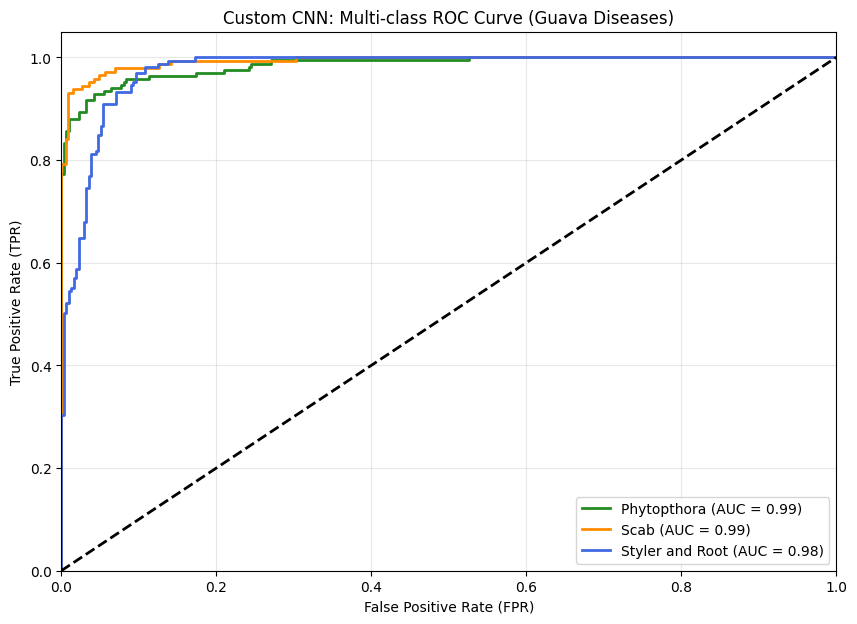

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get predicted probabilities
model.eval()
all_probs = []
all_labels = []

print("Calculating probabilities for Custom CNN ROC Curve...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Softmax converts raw output to probabilities for each class
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Prepare labels for 3-class ROC (One-vs-Rest)
n_classes = 3
bin_labels = label_binarize(all_labels, classes=[0, 1, 2])
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Compute ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(bin_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the results
plt.figure(figsize=(10, 7))
# Distinct colors to distinguish this plot from your pre-trained models
colors = ['forestgreen', 'darkorange', 'royalblue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Custom CNN: Multi-class ROC Curve (Guava Diseases)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()